# 04 — Unicorn hunting

Goal: find players whose **combination** of traits is statistically rare relative to their peers, not simply the best players.

## Step 4A — Position spectrum (decision D5)

Three estimates of position, all on the same **1 (G) → 5 (C)** scale:

| Column | Source |
|---|---|
| `position_num` | **listed** on that season's roster (G=1, G-F=2, F-G=2.5, F=3, F-C=3.5, C-F=4, C=5) |
| `position_body` | predicted from **height and weight** only |
| `position_style` | predicted from **how he plays** only: passing, rebounding, rim protection, steals, shot locations, free throws, usage, self-creation, transition (season-relative z-scores, no body measures) |

The gaps are unicorn signals. `style_vs_body < 0` means a big body that plays small (Jokić, Giannis); `style_vs_listed` shows a player who plays bigger or smaller than his listing.

Models are ridge regressions fitted on rotation players (≥ 500 min) from **that season and earlier only**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
from unicorn.plotting import apply_style, BLUE, ORANGE, INK, INK2, MUTED, FIG_DIR
from unicorn.position import add_position_spectrum, style_coefficients
from unicorn.raw import PROJECT_ROOT

apply_style()
traj = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "player_season_trajectories.parquet")
uni = add_position_spectrum(traj)
print(uni.shape)

(7889, 553)


### How well does style predict listed position, on seasons the model has not seen?

The model is fitted on seasons before *t*, and accuracy is measured on season *t*.

,n,MAE_style,R2_style,R2_body
season_start,,,,
2012,341.0,0.533,0.767,0.801
2013,334.0,0.516,0.769,0.830
2014,362.0,0.513,0.773,0.828
2015,346.0,0.484,0.790,0.831
2016,349.0,0.550,0.748,0.805
2017,350.0,0.522,0.766,0.799
2018,354.0,0.525,0.764,0.804
2019,337.0,0.517,0.732,0.790
2020,361.0,0.555,0.710,0.797


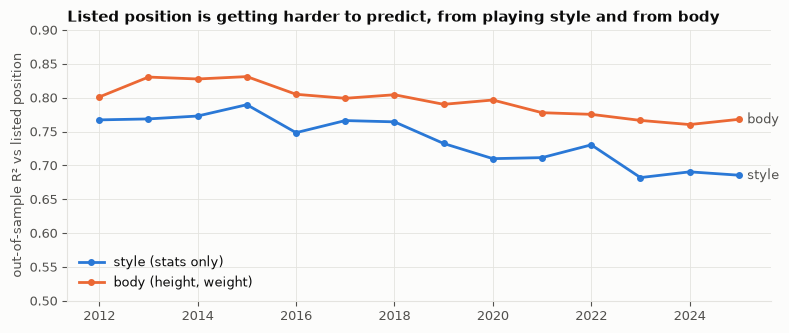

In [2]:
held = add_position_spectrum(traj, holdout=True)
ev = held[(held["position_source"] == "roster") & (held["min"] >= 500) & held["position_style"].notna()]
acc = ev.groupby("season_start").apply(lambda g: pd.Series({
    "n": len(g), "MAE_style": mean_absolute_error(g["position_num"], g["position_style"]),
    "R2_style": r2_score(g["position_num"], g["position_style"]),
    "R2_body": r2_score(g["position_num"], g["position_body"])}), include_groups=False)

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(acc.index, acc["R2_style"], color=BLUE, marker="o", markersize=4, label="style (stats only)")
ax.plot(acc.index, acc["R2_body"], color=ORANGE, marker="o", markersize=4, label="body (height, weight)")
for col, color in [("R2_style", BLUE), ("R2_body", ORANGE)]:
    ax.annotate(col.split("_")[1], (acc.index[-1], acc[col].iloc[-1]), xytext=(6, 0), textcoords="offset points",
                va="center", color=INK2)
ax.set_ylabel("out-of-sample R² vs listed position"); ax.set_ylim(0.5, 0.9)
ax.legend(frameon=False, loc="lower left")
ax.set_title("Listed position is getting harder to predict, from playing style and from body", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "04_position_predictability.png", dpi=150, bbox_inches="tight")
acc.round(3)

### What the style model looks at

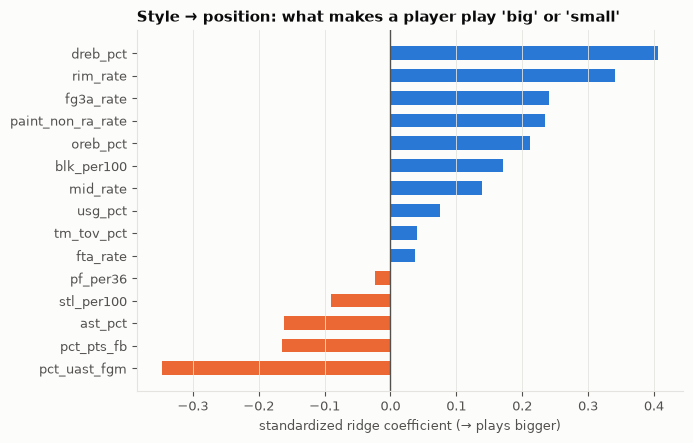

In [3]:
coef = style_coefficients(uni)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(coef.index.str.replace("_z", ""), coef.values, color=np.where(coef > 0, BLUE, ORANGE), height=0.6)
ax.axvline(0, color=INK2, linewidth=1)
ax.set_xlabel("standardized ridge coefficient (→ plays bigger)")
ax.set_title("Style → position: what makes a player play 'big' or 'small'", loc="left")
ax.grid(axis="y", visible=False)
fig.tight_layout(); fig.savefig(FIG_DIR / "04_style_coefficients.png", dpi=150, bbox_inches="tight")

Read the coefficients jointly. The shot-location shares partly sum to one, so e.g. `fg3a_rate` is positive *given* rim and mid-range rates. The clear signals: rebounding and rim shots → big; self-creation, assists and transition scoring → small.

### Body vs style, 2025-26

Each dot is a rotation player. On the diagonal, he plays the position his body suggests. **Below the diagonal, he plays smaller than his body**, which is where big-bodied creators live.

not in 2025-26 rotation sample: []


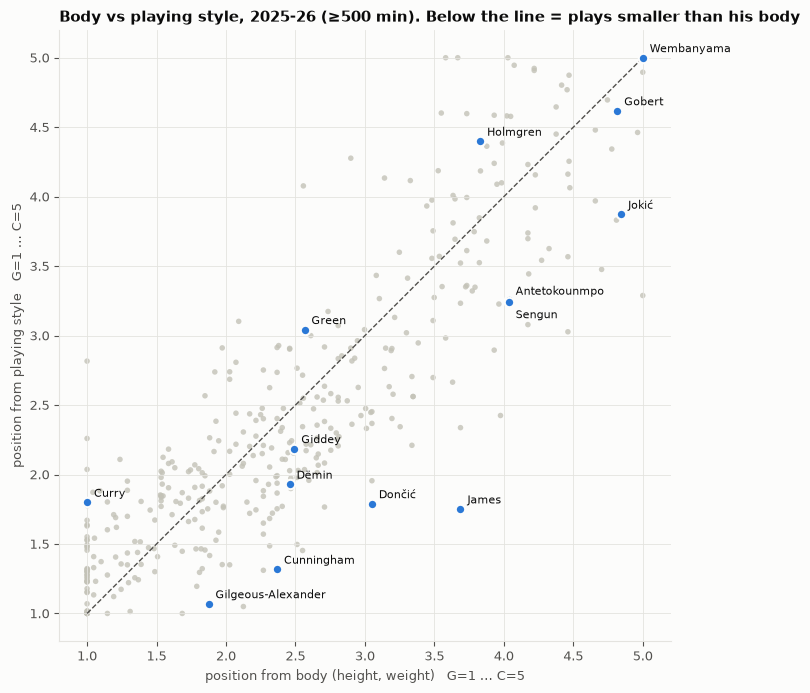

In [4]:
s = uni[(uni["season"] == "2025-26") & (uni["min"] >= 500)]
highlight = ["Nikola Jokić", "Giannis Antetokounmpo", "Victor Wembanyama", "LeBron James", "Luka Dončić",
             "Stephen Curry", "Josh Giddey", "Egor Dëmin", "Rudy Gobert", "Shai Gilgeous-Alexander", "Cade Cunningham",
             "Chet Holmgren", "Alperen Sengun", "Draymond Green"]
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([1, 5], [1, 5], color=INK2, linewidth=1, linestyle="--")
ax.scatter(s["position_body"], s["position_style"], s=16, color=MUTED, edgecolor="none", alpha=0.8)
h = s[s["player_name"].isin(highlight)]
ax.scatter(h["position_body"], h["position_style"], s=46, color=BLUE, edgecolor="#fcfcfb", linewidth=1.5, zorder=3)
label_offsets = {"Alperen Sengun": (5, -12)}  # avoid overlapping Antetokounmpo
for _, r in h.iterrows():
    ax.annotate(r["player_name"].split()[-1], (r["position_body"], r["position_style"]),
                xytext=label_offsets.get(r["player_name"], (5, 4)),
                textcoords="offset points", fontsize=8, color=INK)
ax.set_xlabel("position from body (height, weight)   G=1 … C=5"); ax.set_ylabel("position from playing style   G=1 … C=5")
ax.set_xlim(0.8, 5.2); ax.set_ylim(0.8, 5.2); ax.set_aspect("equal")
ax.set_title("Body vs playing style, 2025-26 (≥500 min). Below the line = plays smaller than his body", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "04_body_vs_style_2025_26.png", dpi=150, bbox_inches="tight")
missing = sorted(set(highlight) - set(h["player_name"]))
print("not in 2025-26 rotation sample:", missing)

In [5]:
cols = ["player_name", "season", "height_in", "position_listed", "position_num", "position_body", "position_style", "style_vs_body"]
rot = uni[uni["min"] >= 1000]
print("Plays smallest relative to his body (all seasons, ≥1000 min):")
display(rot.nsmallest(12, "style_vs_body")[cols].round(2))
print("Plays biggest relative to his body:")
display(rot.nlargest(8, "style_vs_body")[cols].round(2))

Plays smallest relative to his body (all seasons, ≥1000 min):


,player_name,season,height_in,position_listed,position_num,position_body,position_style,style_vs_body
356,LeBron James,2019-20,81.0,F,3.0,3.74,1.37,-2.37
357,LeBron James,2020-21,81.0,F,3.0,3.74,1.73,-2.02
4593,Ben Simmons,2020-21,83.0,G-F,2.0,4.01,2.02,-1.99
362,LeBron James,2025-26,81.0,F,3.0,3.69,1.75,-1.94
360,LeBron James,2023-24,81.0,F,3.0,3.73,1.82,-1.91
4167,Joe Ingles,2022-23,81.0,F-G,2.5,3.13,1.24,-1.89
351,LeBron James,2014-15,80.0,F,3.0,3.27,1.41,-1.85
359,LeBron James,2022-23,81.0,F,3.0,3.75,2.03,-1.72
1422,Brook Lopez,2025-26,85.0,C,5.0,5.00,3.29,-1.71
355,LeBron James,2018-19,80.0,F,3.0,3.41,1.70,-1.71


Plays biggest relative to his body:


,player_name,season,height_in,position_listed,position_num,position_body,position_style,style_vs_body
4825,Gary Payton II,2025-26,74.0,G,1.0,1.00,2.82,1.82
345,Reggie Evans,2012-13,80.0,F,3.0,3.22,5.00,1.78
2146,Ed Davis,2018-19,82.0,C,5.0,3.32,5.00,1.68
2431,Bismack Biyombo,2013-14,81.0,C-F,4.0,3.38,5.00,1.62
2433,Bismack Biyombo,2015-16,81.0,C-F,4.0,3.40,5.00,1.60
2432,Bismack Biyombo,2014-15,81.0,C-F,4.0,3.38,4.97,1.59
2590,Kenneth Faried,2011-12,80.0,F,3.0,2.84,4.42,1.58
7391,Moussa Diabaté,2024-25,81.0,F,3.0,2.90,4.47,1.57


In [6]:
print("Egor Dëmin:")
uni.loc[uni["player_id"] == 1642856, cols + ["min"]].round(2)

Egor Dëmin:


,player_name,season,height_in,position_listed,position_num,position_body,position_style,style_vs_body,min
7829,Egor Dëmin,2025-26,80.0,G,1.0,2.46,1.93,-0.53,1308.21


### Step 4A findings

- **Style predicts listed position well**: out-of-sample R² 0.68–0.79, typically about half a position off. Body predicts slightly better (0.76–0.83).
- **The league is becoming positionless.** Both fall over time: style R² from about 0.77 (2012-18) to about 0.69 (2023-26), body from about 0.83 to about 0.77. Listed positions are converging less with both body and role.
- **What "plays big"**: defensive rebounding, rim attempts, offensive rebounding, blocks. **What "plays small"**: self-creation (unassisted FG share, the strongest), assists, transition scoring, steals.
- **Biggest body-vs-style gaps (≥ 1000 min, all seasons):**
  - **Bodies playing smaller:** LeBron James (repeatedly, down to −2.4 positions), Ben Simmons, Joe Ingles, Brook Lopez 2025-26 (a 7-1 center who now plays like a forward), Andrea Bargnani.
  - **Bodies playing bigger:** Gary Payton II, Reggie Evans, Biyombo, Faried (undersized rebounders and rim runners).
- **2025-26:** Luka, Cade, SGA and LeBron sit well below the line (big ball-handlers); Jokić and Giannis/Sengün are bigs who play like forwards; Holmgren plays bigger than his frame; Wembanyama is a true 5 in both body and style.
- **Egor Dëmin** (rookie, 1,308 min): listed G, 6-8, **body ≈ 2.5 (wing), style ≈ 1.9 (guard)**, so he plays about half a position smaller than his body. That's a mild version of the big-ball-handler profile, not yet an extreme one.